# 🩺 Drug Prescription Classifier

Predicting the appropriate drug for a patient based on age, sex, blood pressure, cholesterol level, and sodium-to-potassium ratio, using a Decision Tree algorithm.

**Dataset:** [drug200.csv](drug200.csv) — 200 patient records with 5 features and a target label (drugA, drugB, drugC, drugX, drugY)

**Final model accuracy:** 98.3%

In [10]:
import numpy as np 
import pandas as pd
import sklearn
from sklearn.tree import DecisionTreeClassifier

## 1. Load & Explore Data

Load the dataset and inspect its basic structure.

In [11]:
df = pd.read_csv("drug200.csv", delimiter=",")
df[0:5]

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [12]:
df.shape

(200, 6)

In [13]:
df.columns

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')

In [14]:
X = df[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']].values
X[0:5]

array([[23, 'F', 'HIGH', 'HIGH', 25.355],
       [47, 'M', 'LOW', 'HIGH', 13.093],
       [47, 'M', 'LOW', 'HIGH', 10.114],
       [28, 'F', 'NORMAL', 'HIGH', 7.798],
       [61, 'F', 'LOW', 'HIGH', 18.043]], dtype=object)

## 2. Preprocessing

The Sex, BP, and Cholesterol columns are categorical, so they're converted to numeric values using `LabelEncoder` so the model can use them.

In [15]:
from sklearn import preprocessing
le_sex = preprocessing.LabelEncoder()
le_sex.fit(['F','M'])
X[:,1] = le_sex.transform(X[:,1]) 


le_BP = preprocessing.LabelEncoder()
le_BP.fit([ 'LOW', 'NORMAL', 'HIGH'])
X[:,2] = le_BP.transform(X[:,2])


le_Chol = preprocessing.LabelEncoder()
le_Chol.fit([ 'NORMAL', 'HIGH'])
X[:,3] = le_Chol.transform(X[:,3]) 

X[0:5]

array([[23, 0, 0, 0, 25.355],
       [47, 1, 1, 0, 13.093],
       [47, 1, 1, 0, 10.114],
       [28, 0, 2, 0, 7.798],
       [61, 0, 1, 0, 18.043]], dtype=object)

In [16]:
y = df['Drug']
y[0:5]

0    drugY
1    drugC
2    drugC
3    drugX
4    drugY
Name: Drug, dtype: object

## 3. Train/Test Split

Split the data into 70% for training and 30% for testing the model.

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_trainset, X_testset, y_trainset, y_testset = train_test_split(X, y, test_size=0.3, random_state=3)

In [19]:
drugTree = DecisionTreeClassifier(criterion="entropy", max_depth = 4)
drugTree

,criterion,'entropy'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## 4. Build & Train Model

Build a decision tree with `criterion="entropy"` and `max_depth=4` to help prevent overfitting.

In [20]:
drugTree.fit(X_trainset, y_trainset)
DecisionTreeClassifier(criterion="entropy", max_depth = 4)

,criterion,'entropy'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [21]:
predTree = drugTree.predict(X_testset)

In [22]:
print (predTree [0:5])
print (y_testset [0:5])

['drugY' 'drugX' 'drugX' 'drugX' 'drugX']
40     drugY
51     drugX
139    drugX
197    drugX
170    drugX
Name: Drug, dtype: object


## 5. Evaluate Model

Evaluate the model on the test set using accuracy as the metric.

In [23]:
from sklearn import metrics
import matplotlib.pyplot as plt
print("DecisionTree's Accuracy: " , metrics.accuracy_score(y_testset, predTree))

DecisionTree's Accuracy:  0.9833333333333333


## 6. Visualize the Tree

Visualize the decision tree to better understand how the model makes decisions.

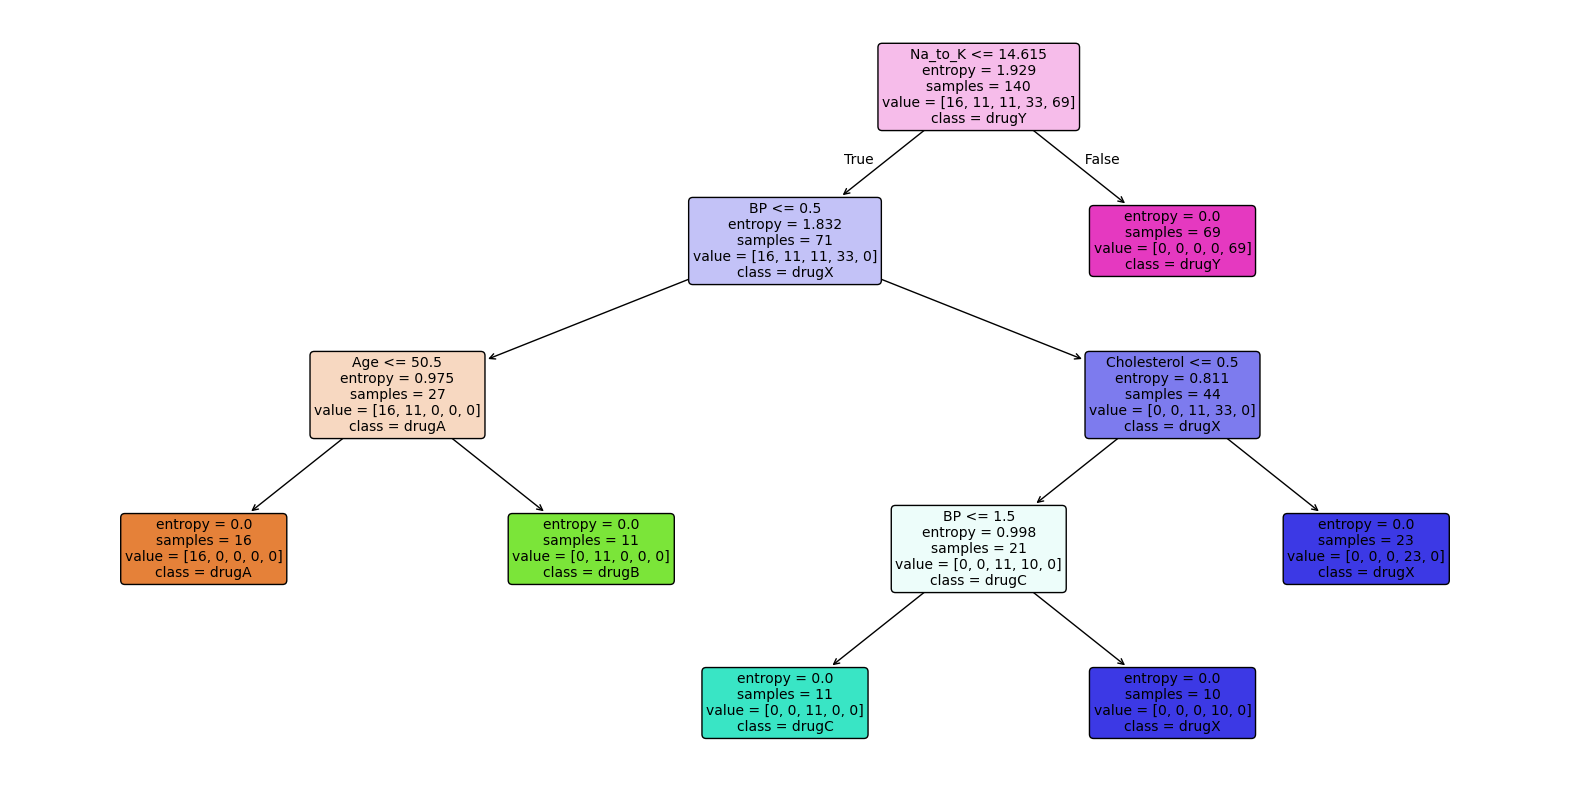

In [27]:
from sklearn.tree import plot_tree

featureNames = df.columns[0:5]

plt.figure(figsize=(20, 10))
plot_tree(drugTree,
          feature_names=featureNames,
          class_names=np.unique(y_trainset),
          filled=True,
          rounded=True,
          fontsize=10)
plt.show()

## 📌 Conclusion

The Decision Tree model achieved **98.3% accuracy** in predicting the appropriate drug based on patient features. The `Na_to_K` feature had the strongest influence on the tree's decisions.